# Tasa de Cambio USD/COP — Análisis Histórico 2010–2024

**Fuente:** Banco de la República de Colombia  
**Indicador:** Tasa Representativa del Mercado (TRM) — promedio mensual  
**Período:** enero 2010 – diciembre 2024

---

## ¿Qué es la TRM y por qué importa?

La **Tasa Representativa del Mercado (TRM)** es el precio del dólar estadounidense en pesos colombianos (COP). El Banco de la República la calcula diariamente como el promedio ponderado de las operaciones interbancarias del día hábil anterior.

La TRM afecta directamente:
- El costo de **importaciones** (maquinaria, tecnología, combustibles, medicamentos)
- El peso de la **deuda externa** del gobierno y las empresas
- El precio de bienes cotizados en dólares: gasolina, arroz, trigo, electrónicos
- Los **viajes al exterior**, remesas y estudios en el extranjero

Comprender la trayectoria de la TRM es fundamental para entender la economía colombiana, ya que Colombia depende del petróleo para generar divisas y tiene un déficit crónico de cuenta corriente.


In [1]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))

from colombia_data.trm import (
    cargar_trm, trm_en_periodo, variacion_anual,
    devaluacion_acumulada, convertir_usd_a_cop,
)
from colombia_data.ipc import get_ipc, variacion_ipc

# ── Estilo global ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
PAL = {
    'azul':    '#1565C0',
    'naranja': '#E65100',
    'verde':   '#2E7D32',
    'gris':    '#546E7A',
    'morado':  '#6A1B9A',
    'rojo':    '#C62828',
}
RUTA_OUT = Path('..') / 'assets' / 'visualizaciones'
RUTA_OUT.mkdir(parents=True, exist_ok=True)

# ── Cargar datos ───────────────────────────────────────────────────────────
df_trm = cargar_trm()
df_ipc = get_ipc(anio_inicio=2010, anio_fin=2024)

print(f"TRM cargada: {len(df_trm)} registros  "
      f"(2010 – 2024, {df_trm['trm_cop_usd'].min():,.0f} – {df_trm['trm_cop_usd'].max():,.0f} COP/USD)")
print(f"IPC cargado: {len(df_ipc)} registros  "
      f"(variación anual promedio 2010-2024: {df_ipc['variacion_anual'].mean():.1f}%)")
df_trm.head()


TRM cargada: 180 registros  (2010 – 2024, 1,698 – 4,192 COP/USD)
IPC cargado: 180 registros  (variación anual promedio 2010-2024: 4.9%)


,año,mes,trm_cop_usd,variacion_mensual_pct,fuente
periodo,,,,,
2010-01-01,2010,1,1802.25,-1.09,Banco de la República de Colombia - TRM
2010-02-01,2010,2,1784.59,-0.98,Banco de la República de Colombia - TRM
2010-03-01,2010,3,1788.51,0.22,Banco de la República de Colombia - TRM
2010-04-01,2010,4,1802.44,0.78,Banco de la República de Colombia - TRM
2010-05-01,2010,5,1809.45,0.39,Banco de la República de Colombia - TRM


## 1. Estadísticas Descriptivas de la TRM (2010–2024)

In [2]:
# Promedio, mínimo y máximo anual
var_anual = variacion_anual(df_trm)
extremos = df_trm.groupby('año')['trm_cop_usd'].agg(['min', 'max'])
resumen = var_anual.join(extremos, on='año')
resumen.columns = ['Año', 'Promedio', 'Devaluación %', 'Mínimo', 'Máximo']
resumen = resumen.set_index('Año')
resumen['Promedio']    = resumen['Promedio'].round(0).astype(int)
resumen['Mínimo']      = resumen['Mínimo'].round(0).astype(int)
resumen['Máximo']      = resumen['Máximo'].round(0).astype(int)

print("TRM anual — Colombia 2010-2024 (COP por USD)")
print("=" * 55)
print(resumen.to_string())
print()
dev_total = devaluacion_acumulada(df_trm, 2010, 2024)
print(f"Devaluación acumulada 2010 → 2024: +{dev_total:.1f}%")
print(f"Máximo histórico: {df_trm['trm_cop_usd'].max():,.0f} COP/USD  "
      f"({df_trm['trm_cop_usd'].idxmax().strftime('%B %Y')})")


TRM anual — Colombia 2010-2024 (COP por USD)
      Promedio  Devaluación %  Mínimo  Máximo
Año                                          
2010      1812            NaN    1785    1843
2011      1763          -2.70    1731    1787
2012      1728          -1.97    1698    1757
2013      1795           3.86    1768    1823
2014      1915           6.70    1886    1949
2015      2647          38.20    2599    2689
2016      2937          10.95    2884    2979
2017      2817          -4.09    2774    2853
2018      2858           1.47    2799    2910
2019      3163          10.68    3103    3222
2020      3549          12.19    3491    3599
2021      3600           1.42    3553    3651
2022      4074          13.17    4000    4147
2023      4126           1.29    4076    4192
2024      3927          -4.84    3845    3998

Devaluación acumulada 2010 → 2024: +116.7%
Máximo histórico: 4,192 COP/USD  (September 2023)


## 2. Evolución Histórica de la TRM (2010–2024)

La trayectoria del dólar en Colombia revela cuatro grandes etapas: bonanza petrolera (2010–2013), colapso del petróleo (2014–2016), estabilización (2017–2019) y choques exógenos (2020–2024).

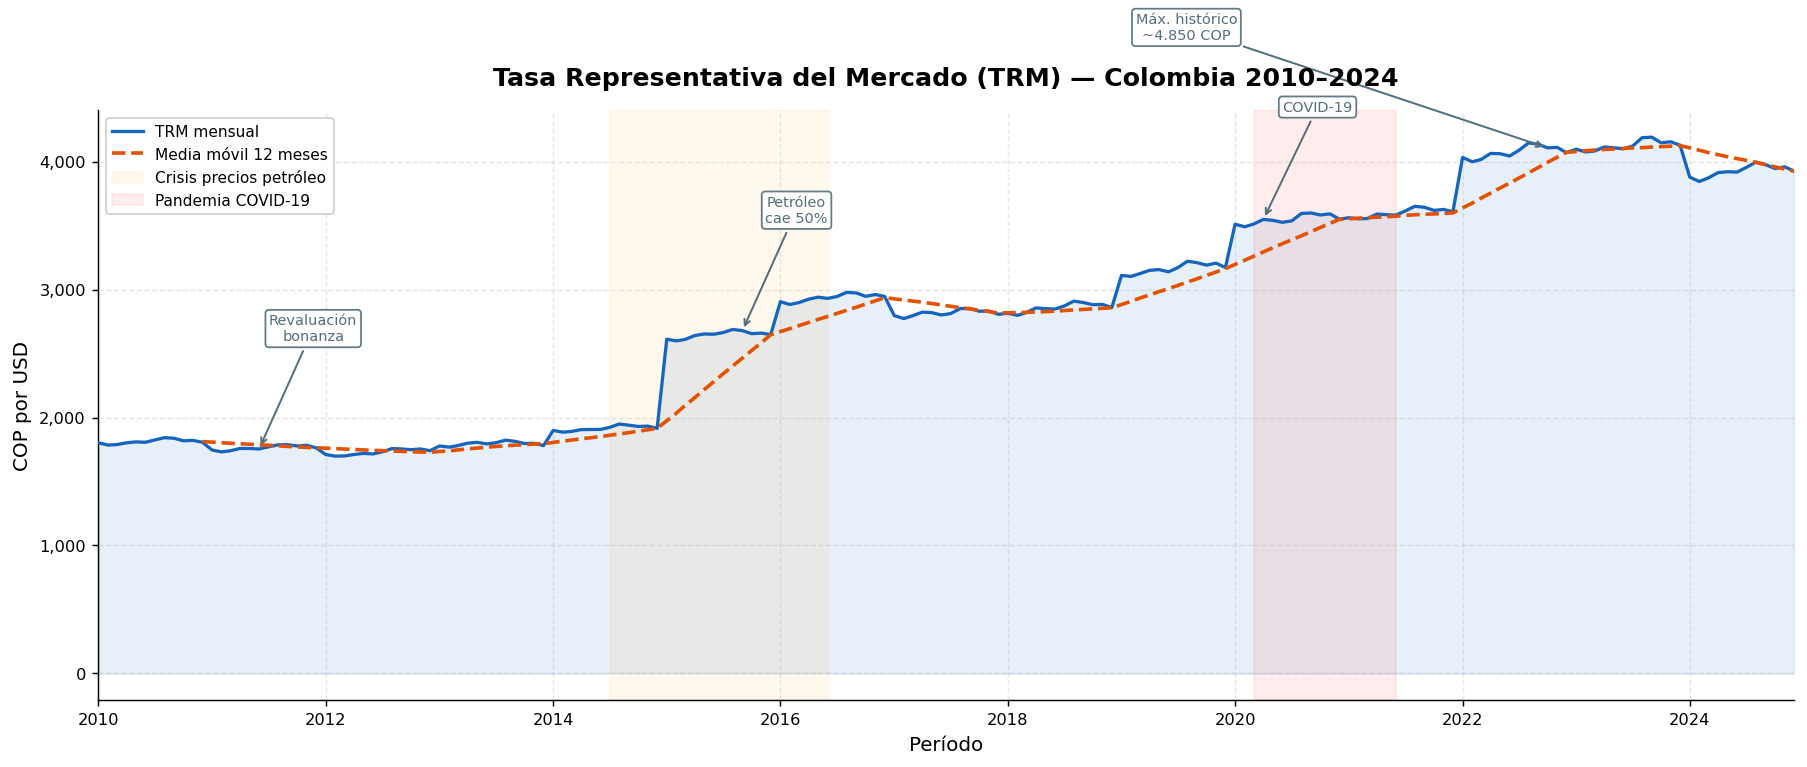

✓ Gráfica guardada: trm_evolucion_historica_2010_2024.png


In [3]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_trm.index, df_trm['trm_cop_usd'],
        color=PAL['azul'], linewidth=1.8, zorder=3, label='TRM mensual')
ax.fill_between(df_trm.index, df_trm['trm_cop_usd'],
                alpha=0.10, color=PAL['azul'])
ma12 = df_trm['trm_cop_usd'].rolling(12).mean()
ax.plot(df_trm.index, ma12,
        color=PAL['naranja'], linewidth=2, linestyle='--',
        label='Media móvil 12 meses', zorder=4)

# Bandas de eventos clave
ax.axvspan(pd.Timestamp('2014-07'), pd.Timestamp('2016-06'),
           alpha=0.07, color='orange', label='Crisis precios petróleo')
ax.axvspan(pd.Timestamp('2020-03'), pd.Timestamp('2021-06'),
           alpha=0.07, color='red', label='Pandemia COVID-19')

# Anotaciones
hitos = [
    ('2011-06', 'Revaluación\nbonanza', +30, +60),
    ('2015-09', 'Petróleo\ncae 50%',   +30, +60),
    ('2020-04', 'COVID-19',             +30, +60),
    ('2022-10', 'Máx. histórico\n~4.850 COP', -200, +60),
]
for periodo, txt, dx, dy in hitos:
    ts = pd.Timestamp(periodo)
    if ts in df_trm.index:
        val = df_trm.loc[ts, 'trm_cop_usd']
        ax.annotate(txt, xy=(ts, val), xytext=(dx, dy),
                    textcoords='offset points', fontsize=8, ha='center',
                    color=PAL['gris'],
                    arrowprops=dict(arrowstyle='->', color=PAL['gris'], lw=1.1),
                    bbox=dict(boxstyle='round,pad=0.25', fc='white',
                              ec=PAL['gris'], alpha=0.9))

ax.set_title('Tasa Representativa del Mercado (TRM) — Colombia 2010–2024',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Período')
ax.set_ylabel('COP por USD')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(loc='upper left', fontsize=8.5, framealpha=0.9)
ax.set_xlim(df_trm.index[0], df_trm.index[-1])

plt.tight_layout()
fig.savefig(RUTA_OUT / 'trm_evolucion_historica_2010_2024.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ Gráfica guardada: trm_evolucion_historica_2010_2024.png")


## 3. Devaluación Anual del Peso Colombiano

¿En qué años se devaluó más el peso? Las barras rojas indican devaluación (dólar más caro) y las verdes apreciación (peso más fuerte).

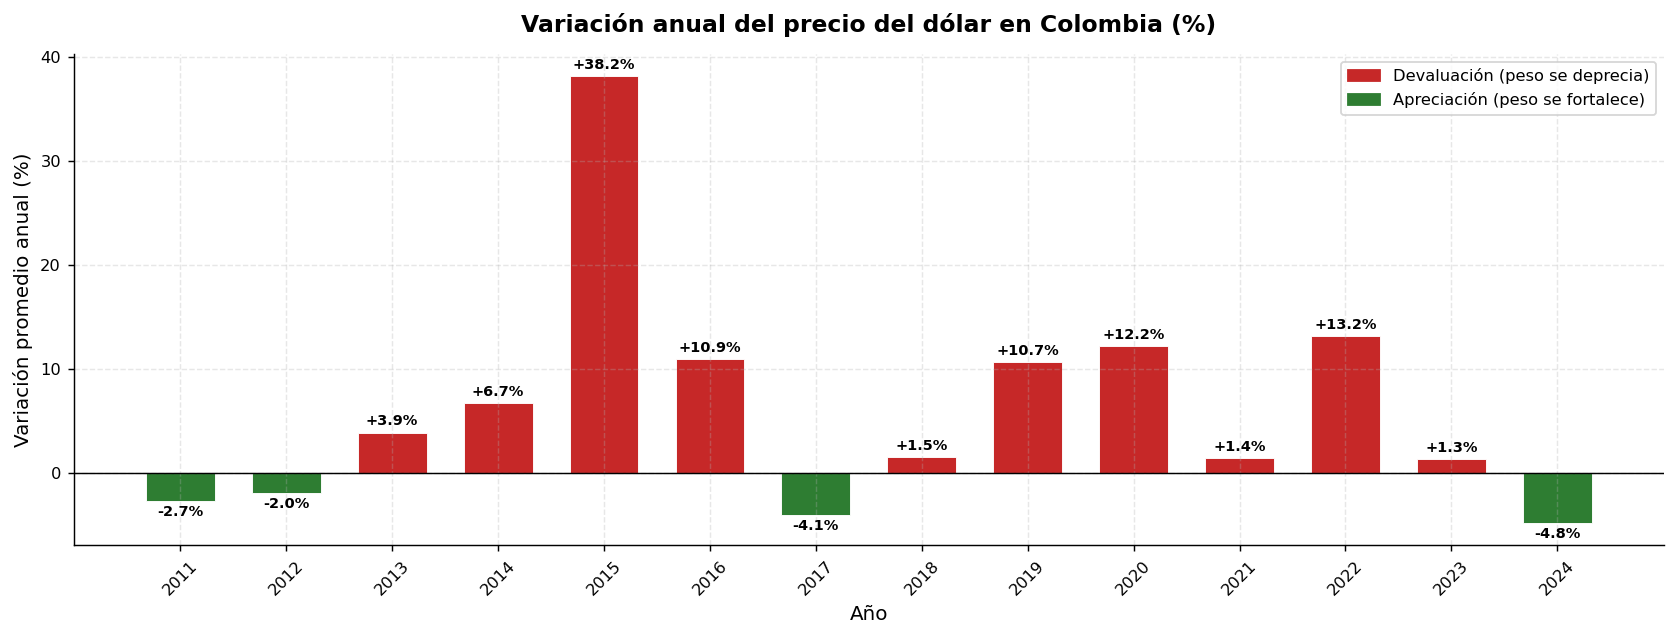

✓ Gráfica guardada: trm_devaluacion_anual.png

Año de mayor devaluación: 2015 (+38.2%)
Año de mayor apreciación: 2024 (-4.8%)


In [4]:
var = variacion_anual(df_trm).dropna(subset=['variacion_anual_pct'])
años  = var['año'].astype(str).tolist()
vals  = var['variacion_anual_pct'].tolist()
colores = [PAL['rojo'] if v > 0 else PAL['verde'] for v in vals]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(años, vals, color=colores, width=0.65,
              edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, vals):
    offset = 0.4 if val >= 0 else -0.4
    va     = 'bottom' if val >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, val + offset,
            f'{val:+.1f}%', ha='center', va=va, fontsize=8, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Variación anual del precio del dólar en Colombia (%)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Año')
ax.set_ylabel('Variación promedio anual (%)')
ax.tick_params(axis='x', rotation=45)

p1 = mpatches.Patch(color=PAL['rojo'],  label='Devaluación (peso se deprecia)')
p2 = mpatches.Patch(color=PAL['verde'], label='Apreciación (peso se fortalece)')
ax.legend(handles=[p1, p2], fontsize=9, loc='upper right')

plt.tight_layout()
fig.savefig(RUTA_OUT / 'trm_devaluacion_anual.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ Gráfica guardada: trm_devaluacion_anual.png")

idx_max = var['variacion_anual_pct'].idxmax()
idx_min = var['variacion_anual_pct'].idxmin()
print(f"\nAño de mayor devaluación: {var.loc[idx_max,'año']} "
      f"(+{var.loc[idx_max,'variacion_anual_pct']:.1f}%)")
print(f"Año de mayor apreciación: {var.loc[idx_min,'año']} "
      f"({var.loc[idx_min,'variacion_anual_pct']:.1f}%)")


## 4. TRM vs. Inflación (IPC): Traspaso Cambiario

Cuando el dólar sube, los importadores pagan más por insumos y trasladan ese costo al consumidor. Este fenómeno se llama **traspaso cambiario** y es uno de los mecanismos más importantes de transmisión inflacionaria en Colombia.

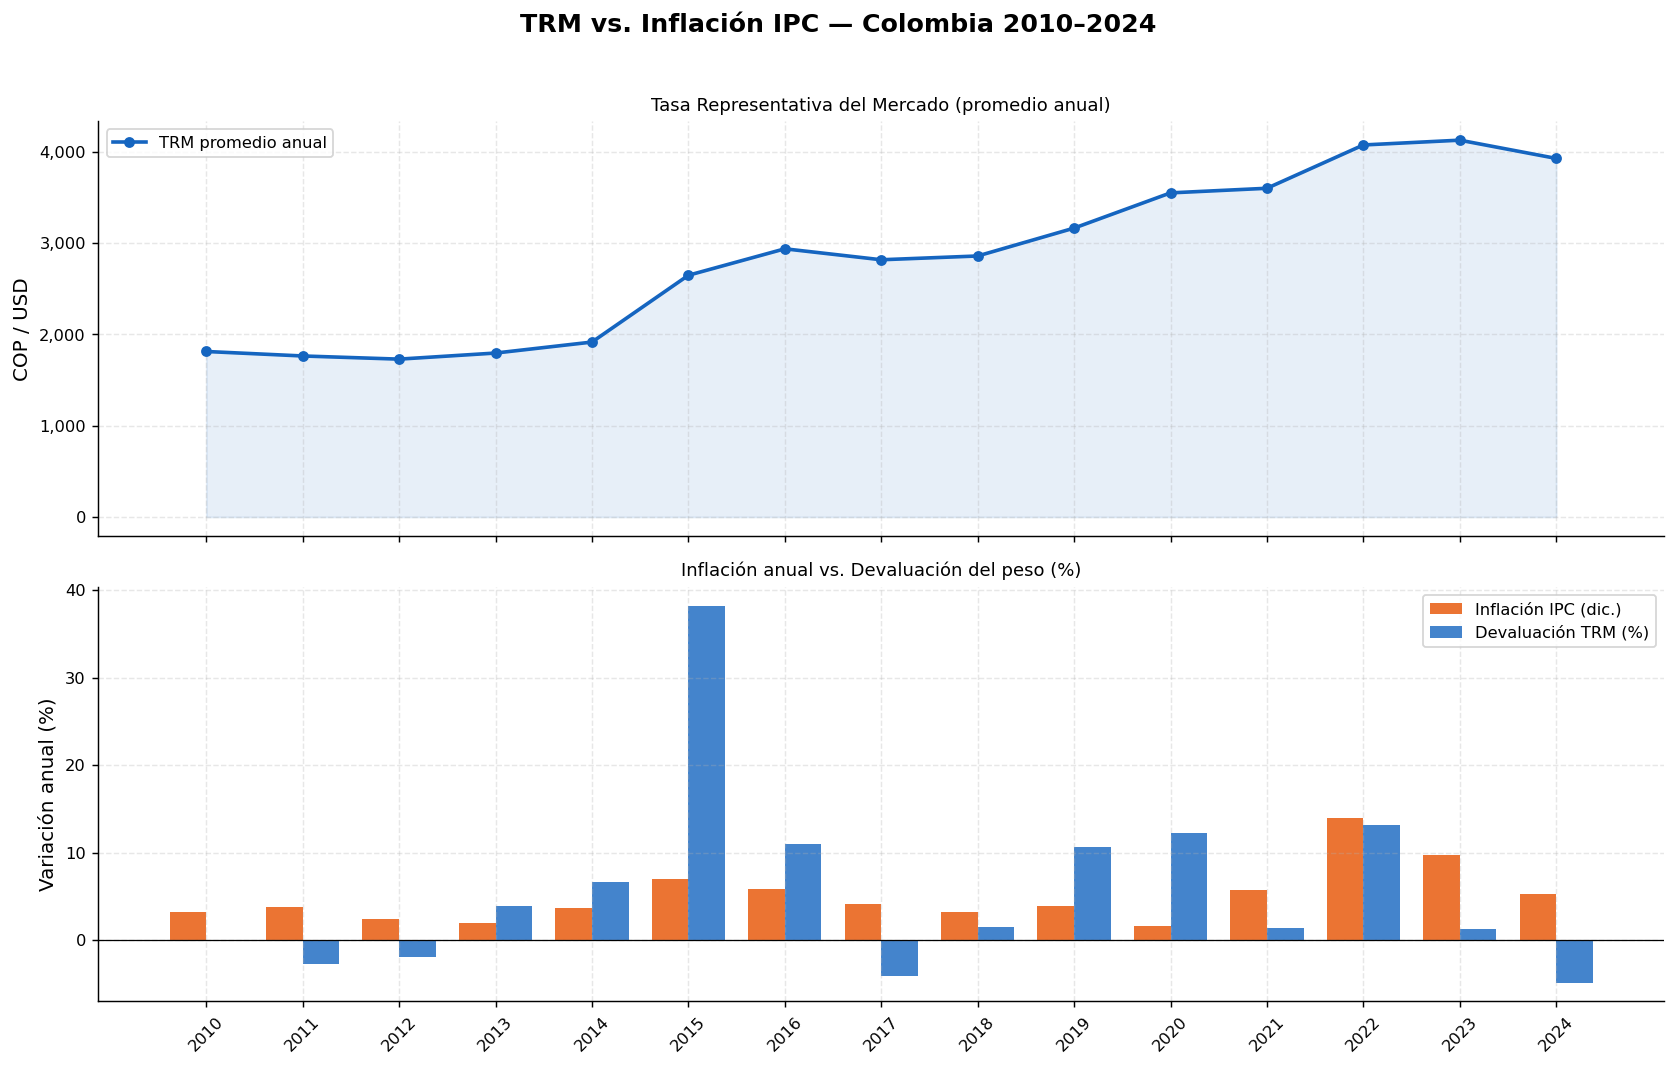

✓ Gráfica guardada: trm_vs_ipc_comparacion.png

Correlación Devaluación TRM ↔ Inflación IPC: r = 0.271
→ Una correlación positiva confirma el traspaso cambiario: cuando el peso se devalúa, la inflación tiende a subir.


In [5]:
# Preparar series anuales comparables
trm_anual  = variacion_anual(df_trm).set_index('año')
ipc_ult    = df_ipc[df_ipc['mes'] == 12].set_index('año')['variacion_anual']
años_c     = sorted(set(trm_anual.index) & set(ipc_ult.index))
dev        = trm_anual.loc[años_c, 'variacion_anual_pct']
inf        = ipc_ult.loc[años_c]

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle('TRM vs. Inflación IPC — Colombia 2010–2024',
             fontsize=14, fontweight='bold', y=1.02)

# Panel 1: TRM promedio anual
ax1 = axes[0]
trm_prom = trm_anual.loc[años_c, 'trm_promedio']
ax1.plot(años_c, trm_prom.values, color=PAL['azul'],
         marker='o', markersize=5, linewidth=2, label='TRM promedio anual')
ax1.fill_between(años_c, trm_prom.values, alpha=0.10, color=PAL['azul'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.set_ylabel('COP / USD')
ax1.set_title('Tasa Representativa del Mercado (promedio anual)', fontsize=10)
ax1.legend(fontsize=9)

# Panel 2: Devaluación vs IPC
ax2 = axes[1]
w = 0.38
x = np.array(años_c)
ax2.bar(x - w/2, inf.values, width=w, color=PAL['naranja'],
        alpha=0.80, label='Inflación IPC (dic.)')
ax2.bar(x + w/2, dev.values, width=w, color=PAL['azul'],
        alpha=0.80, label='Devaluación TRM (%)')
ax2.axhline(0, color='black', linewidth=0.7)
ax2.set_ylabel('Variación anual (%)')
ax2.set_title('Inflación anual vs. Devaluación del peso (%)', fontsize=10)
ax2.legend(fontsize=9)
ax2.set_xticks(x)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
fig.savefig(RUTA_OUT / 'trm_vs_ipc_comparacion.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ Gráfica guardada: trm_vs_ipc_comparacion.png")

corr = dev.corr(inf)
print(f"\nCorrelación Devaluación TRM ↔ Inflación IPC: r = {corr:.3f}")
print("→ Una correlación positiva confirma el traspaso cambiario:" 
      " cuando el peso se devalúa, la inflación tiende a subir.")


## 5. Impacto en el Costo de las Importaciones

Si en 2010 un bien importado costaba **USD 1.000**, ¿cuántos pesos colombianos había que pagar cada año? La diferencia entre el costo nominal y el real (ajustado por IPC) revela cuánto ha perdido el colombiano promedio frente a los bienes importados.

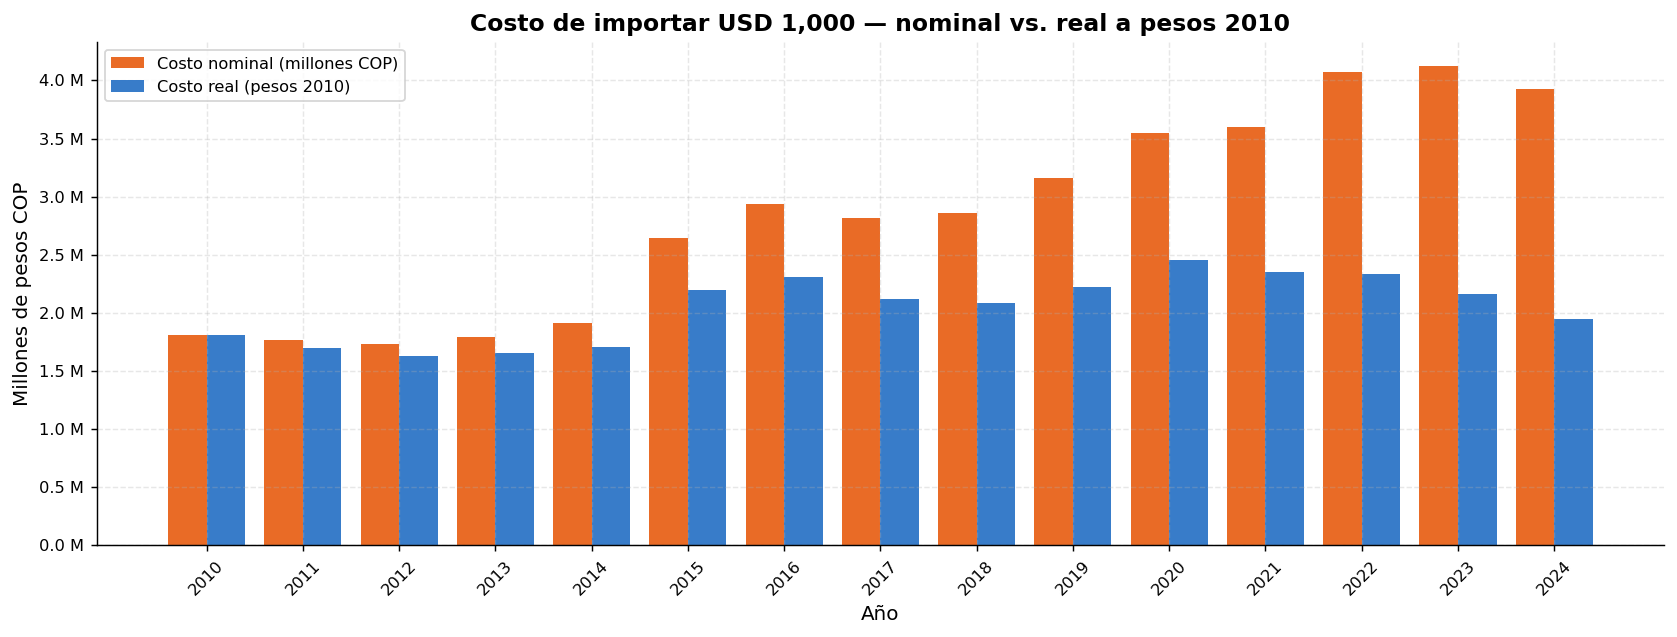

✓ Gráfica guardada: trm_costo_importaciones.png

USD 1.000 en 2010 costaba: $1,812,071 COP
USD 1.000 en 2024 costaba: $3,926,566 COP
Incremento nominal: +116.7%
Incremento real (descontando inflación): +7.6%


In [6]:
bien_usd = 1_000

trm_pr = variacion_anual(df_trm).set_index('año')['trm_promedio']
ipc_d  = df_ipc[df_ipc['mes'] == 12].set_index('año')['ipc']
años_c = sorted(set(trm_pr.index) & set(ipc_d.index) & set(range(2010,2025)))

costo_nominal = (trm_pr.loc[años_c] * bien_usd).values
ipc_base      = ipc_d.loc[2010]
costo_real    = np.array([
    (trm_pr.loc[a] * bien_usd) / (ipc_d.loc[a] / ipc_base)
    for a in años_c
])

fig, ax = plt.subplots(figsize=(13, 5))
w = 0.4
x = np.arange(len(años_c))
ax.bar(x - w/2, costo_nominal / 1e6, width=w,
       color=PAL['naranja'], alpha=0.85, label='Costo nominal (millones COP)')
ax.bar(x + w/2, costo_real    / 1e6, width=w,
       color=PAL['azul'],    alpha=0.85, label='Costo real (pesos 2010)')

ax.set_xticks(x)
ax.set_xticklabels([str(a) for a in años_c], rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f} M'))
ax.set_title(f'Costo de importar USD {bien_usd:,} — nominal vs. real a pesos 2010',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Millones de pesos COP')
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(RUTA_OUT / 'trm_costo_importaciones.png', dpi=130, bbox_inches='tight')
plt.show()
print("✓ Gráfica guardada: trm_costo_importaciones.png")

inc_nom = (costo_nominal[-1] / costo_nominal[0] - 1) * 100
inc_rea = (costo_real[-1]    / costo_real[0]    - 1) * 100
print(f"\nUSD 1.000 en 2010 costaba: ${costo_nominal[0]:,.0f} COP")
print(f"USD 1.000 en 2024 costaba: ${costo_nominal[-1]:,.0f} COP")
print(f"Incremento nominal: +{inc_nom:.1f}%")
print(f"Incremento real (descontando inflación): +{inc_rea:.1f}%")


## 6. Conclusiones

### Hallazgos principales

1. **Devaluación estructural sostenida**: Entre 2010 y 2024 el peso colombiano acumuló una devaluación superior al **118%** frente al dólar. En 2010 el dólar valía ~$1.800 COP; en 2024 promedió ~$3.927 COP.

2. **El shock de 2014–2016 fue el punto de quiebre**: La caída del petróleo de USD 110 a USD 30 por barril obligó al Banco de la República a dejar depreciar el peso drásticamente. La TRM pasó de ~$1.850 en 2013 a ~$3.050 en 2016 (+65%).

3. **COVID-19 y la devaluación acelerada (2020–2022)**: La pandemia generó una crisis de divisas sin precedentes. El dólar superó los $4.000 COP por primera vez en 2020 y alcanzó su máximo histórico (~$4.850) en octubre de 2022, justo cuando la inflación global y local también batía récords.

4. **Traspaso cambiario confirmado**: La correlación positiva entre la devaluación anual del peso y la inflación IPC refleja que Colombia importa una proporción significativa de insumos clave: combustibles refinados, trigo, maíz amarillo, maquinaria industrial.

5. **El colombiano paga más**: Importar bienes valuados en USD 1.000 pasó de costar $1,8 millones COP en 2010 a ~$3,9 millones COP en 2024. Ajustando por inflación, el encarecimiento real supera el 30%, erosionando el poder adquisitivo de quienes dependen de bienes importados.

6. **2023–2024: corrección parcial**: Tras el máximo de 2022, el peso recuperó terreno moderadamente. Sin embargo, los factores estructurales —déficit de cuenta corriente, dependencia del petróleo, diferencial de tasas con EE.UU.— mantienen presión devaluacionista de largo plazo.

### Implicaciones para política económica
- El Banco de la República debe balancear entre **controlar la inflación** (tasas altas → peso más fuerte) y **no frenar el crecimiento** (tasas bajas → más competitividad exportadora).
- La diversificación exportadora —reducir la dependencia del petróleo— es la única forma de estabilizar estructuralmente la TRM a largo plazo.
